$\newcommand{\bfL}{{\bf L}}$
$\newcommand{\bfA}{{\bf A}}$
$\newcommand{\bfB}{{\bf B}}$
$\newcommand{\bfx}{{\bf x}}$
$\newcommand{\bfv}{{\bf v}}$
$\newcommand{\bfna}{{\bf\nabla}}$

## Magnetic field, its derivatives, and the null point

### Biot-Savart field of a circular loop

The infinitesimal field from a parametrically defined current loop $\bfL(t)=(a\cos(t),a\sin(t),0)$ is
$$
\begin{aligned}
\bfB &= \frac{\dot\bfL\times(\bfx-\bfL)}{D^3},\quad D\equiv|\bfx-\bfL|,\\
B_x &= \frac{\dot L_y(z-L_z) - \dot L_z(x-L_x)}{D^3} = \frac{\dot L_yz}{D^3},\\
B_y &= \frac{\dot L_y(z-L_x) - \dot L_x(z-L_z)}{D^3} = -\frac{\dot L_xz}{D^3},\\
B_z &= \frac{\dot L_x(y-L_y) - \dot L_y(x-L_x)}{D^3} = \frac{L_x\dot L_y-L_y\dot L_x + \dot L_xy - \dot L_y x}{D^3}.
\end{aligned}
$$
Here the condition $L_z\equiv0$ is applied for a flat $(x,y)$ loop.  In terms of the parameter $t$,
$$
\begin{aligned}
B_x &= \frac{az\cos(t)}{D^3},\\
B_y &= \frac{az\sin(t)}{D^3},\\
B_z &= a\frac{a - x\cos(t) - y\sin(t)}{D^3}.
\end{aligned}
$$
Field derivatives:
$$
\begin{aligned}
B_{x,x} &=-3az\frac{\cos(t)(x-a\cos(t))}{D^5},\\
B_{y,y} &=-3az\frac{\sin(t)(y-a\sin(t))}{D^5},\\
B_{x,z} &=\frac{a\cos(t)}{D^3}\left(1-3\frac{z^2}{D^2}\right),\\
B_{z,z} &= 3az\frac{-a + x\cos(t) + y\sin(t)}{D^5}.
\end{aligned}
$$
It is verified that $\nabla\cdot\bfB=B_{x,x}+B_{y,y}+B_{z,z}=0$.

### The null ("$X$") point

The field in the plane $y=0$ is expressed through the vector potential $A$ as
$(B_x, B_z) = (-\partial_zA_y, \partial_xA_y),$
meaning that the countour lines of $A_y(x, z)$ are the magnetic lines, and the $X$ point is a saddle point of $A_y$.  The $X$ point condition, however, can be written in terms of $(B_x,B_z)$ only.  The field is zero at the target point $(X,Z)$ and its Taylor expansion to first order is
$$B_x = B_{x,x}(x-X)+B_{x,z}(z-Z),$$
$$B_z = B_{z,x}(x-X)+B_{z,z}(z-Z).$$
The commas denote differentiation.  Unlike the field $B$, its derivatives are not zero at the $X$ point.

Magnetic lines near the $X$ point are either hyperbolas or intersecting separatrices passing through the point.
The separatrices are the directions where the field is collinear with the displacement, $B_z/B_x = \pm(z-Z)/(x-X)$.  The desired direction is $T=(z-Z)/(x-X)=\tan(36^\circ)$, where $T$ is the tangent of the required angle between the field and the board plane ($54^\circ$ with respect to the normal).  The collinearity condition yields
$$
\frac{B_{z,x} + B_{z,z}T}{B_{x,x}+B_{x,z}T} = \pm T.
$$
For curl-free field, we have $B_{z,x} = B_{x,z}=0$, so the angle condition involves only 3 derivatives.  For the plus sign above, the slope of the separatrix is determined from the quadratic equation
$$
B_{x,z}T^2 + (B_{x,x} - B_{z,z})T - B_{z,x} = 0\quad\Longrightarrow\quad
T=\frac{C+\sqrt{C^2+4B_{x,z}B_{z,x}}}{2B_{x,z}},\quad C\equiv B_{z,z}-B_{x,x}.
$$
This expression agrees with the fact [known to AI] that the separatrix lines are the eigenvectors of the feld's Jacobian matrix:
$$
J=\left(\begin{array}{ll} B_{x,x} & B_{x,z}\\ B_{z,x} & B_{z,z}\end{array}\right),\quad J\bfv=\lambda\bfv,\quad
\bfv_{1,2}=\left(C\pm\sqrt{C^2+4B_{x,z}B_{z,x}}, 2B_{x,z}\right).
$$
Note that the two eignevectors are orthogonal: $\bfv_1\cdot\bfv_2=0$ due to the curl-free field, $B_{x,z}=B_{z,x}$, as expected.  The expression for the eigenvectors in `mark_x()` is used for a visual check of the $X$ point separatrix relative to magnetic field lines.

In [46]:
# self-contained interactive tool

from dataclasses import dataclass
from scipy.optimize import minimize
import scipy.integrate as integrate
from itertools import combinations
import numpy as np

@dataclass
class Params:
    '''
    Configuration of two current loops
    '''
    x1: float = -1.0    # x-locations of loop centers at y=0
    x2: float =  1.0
    z1: float =  0.0    # z-heights of the loops
    z2: float = -0.01
    a1: float =  1.0    # radii of the loops
    a2: float =  2.0
    I_ratio: float = -1 # I2/I1
    def __str__(self): # make Params object printable
        n = 4 # precision
        return \
        f'(x1,x2)=({round(self.x1,n)},{round(self.x2,n)}), ' + \
        f'(z1,z2)=({round(self.z1,n)},{round(self.z2,n)}), ' + \
        f'(a1,a2)=({round(self.a1,n)},{round(self.a2,n)}), ' + \
        f'I_ratio={round(self.I_ratio,n)}'

@dataclass
class ParamBounds:
    '''
    Acceptable (min, max) for each param above
    '''
    x1 = (-3, 3)
    x2 = (-3, 3)
    z1 = (-0.02, 0)
    z2 = (-0.02, 0)
    a1 = (0.5, 3)
    a2 = (0.5, 3)
    I_ratio = (-2, -0.5)

def dB(x, y, z, a, t):
    '''
    Magnetic field at (x, y, z) of infinitesimal piece of loop with unit current
    lying in (x,y) plane with the center at the origin and radius a.
    The loop is defined parametrically as x=a*cos(t), y=a*sin(t), z=0
    '''
    cos = np.cos(t)
    sin = np.sin(t)
    num = np.array([a*z*cos, a*z*sin, a*a - a*x*cos - a*y*sin])
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D3 = D2*np.sqrt(D2)
    return num/D3

def dB_derivs(x, z, a, t):
    '''
    Derivatives of infinitesimal B at y=0
    '''
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (a*sin)**2 + z**2
    D3 = D2*np.sqrt(D2)
    D5 = D2*D3

    Bxx = -3*a*z*cos*(x - a*cos)/D5
    Bxz = a*cos/D3*(1 - 3*z*z/D2)
    Bzz = 3*a*z*(-a + x*cos)/D5
    return np.array([Bxx, Bxz, Bzz])

def loop_B(x, y, z, a):
    '''
    Magnetic field of full loop at the origin -- t-integral of dB over the loop.
    Returns ([Bx, By, Bz], integration_error).
    '''
    return integrate.quad_vec(lambda t: dB(x, y, z, a, t), 0, 2*np.pi)

def loop_B_derivs(x, z, a):
    '''
    t-integral of dB_derivs over the loop.
    Returns ([Bxx, Bxz, Bzz], integration_error).
    '''
    return integrate.quad_vec(lambda t: dB_derivs(x, z, a, t), 0, 2*np.pi)

def total_B(x, z, x1, x2, z1, z2, a1, a2, I1, I2): # (Bx, Bz)
    B1 = loop_B(x - x1, 0, z - z1, a1)[0]
    B2 = loop_B(x - x2, 0, z - z2, a2)[0]
    return np.array([I1*B1[0] + I2*B2[0], I1*B1[2] + I2*B2[2]])

def total_B_derivs(x, z, x1, x2, z1, z2, a1, a2, I1, I2):
    '''
    Magnetic field in the plane y=0 of two current loops with centers
    at (x_i, 0, z_i), radii a_i, and currents I_i.
    z_i are small nonpositive distances indicating loop positions below the board plane.
    '''
    B1_derivs = loop_B_derivs(x - x1, z - z1, a1)[0]
    B2_derivs = loop_B_derivs(x - x2, z - z2, a2)[0]
    #print(f'B1_derivs={B1_derivs}')
    return I1*B1_derivs + I2*B2_derivs

def compute_jac_eigenvector(Bxx, Bxz, Bzz):
    '''
    The eigenvectors are supposed to define the separatrix near X-point
    '''
    C = Bzz - Bxx
    D = np.sqrt(C*C + (2*Bxz)**2)
    evec = (C + D, 2*Bxz) # the other one is (C - D, 2*Bxz)
    # print(f'evec={evec}')
    return evec

def search_params(null_x, null_z, vars):
    '''
    Minimize square magnetic field at the given point (null_x, 0, null_z) starting with
    default Params and varying one or more specified params ('vars') while holding others constant.
    Variable param names example:  vars = ['x1', 'x2'].
    '''
    pp = Params()  # default/initial params
    bb = ParamBounds()
    def utility(values): # values of vars
        '''
        Squared magnetic field at (null_x, 0, null_z).
        '''
        for var, value in zip(vars, values):
            setattr(pp, var, value) # set pp.<var> = value
        I1, I2 = 1, pp.I_ratio
        return np.sum(np.square(
            total_B(null_x, null_z, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, I1, I2)
        ))
    initial_values = [getattr(pp, var) for var in vars] # use default pp.<var> as initial guess
    bounds         = [getattr(bb, var) for var in vars] # extract bounds for the vars
    result = minimize(utility, initial_values, bounds=bounds)
    return result # object containing results of optimization

In [47]:
# target point in cm for zero magnetic field:
null_x, null_z = np.array([0.0]), np.array([1.5])

def optimize_over_all_param_combinations(dim):
    '''
    Select various combinations of params to play with.
    dim = 2 makes all possible pairs.
    dim = 3 makes all possible triples for deeped search.
    Because of varying effect of params, and their bounds,
    not all sets of vars can make zero B at the target point.
    '''
    vars_tuples = list(combinations(['x1', 'x2', 'z1', 'z2', 'a1', 'a2', 'I_ratio'], dim))
    # print(vars_tuples) #  [('x1', 'x2', 'z1'), ('x1', 'x2', 'z2'), etc]
    results = [] # for each vars_tuple
    for idx, vars in enumerate(vars_tuples):
        result = search_params(null_x, null_z, vars)
        results.append(result)
        print(f'Run {idx:02d}:  {vars} -> {result.x}: B2 -> {result.fun}')
        # review the output for next steps
    return vars_tuples, results

dim = 3
vars_tuples, results = optimize_over_all_param_combinations(dim)

Run 00:  ('x1', 'x2', 'z1') -> [1.62176406e-06 2.94928187e-06 0.00000000e+00]: B2 -> 0.2751528210344803
Run 01:  ('x1', 'x2', 'z2') -> [ 2.39954952e-06  2.21415304e-06 -2.00000000e-02]: B2 -> 0.2632327172850572
Run 02:  ('x1', 'x2', 'a1') -> [0.44271644 0.4699058  1.90149374]: B2 -> 1.4660275217516372e-10
Run 03:  ('x1', 'x2', 'a2') -> [0.52960238 0.53492667 1.01269152]: B2 -> 5.609525276203459e-13
Run 04:  ('x1', 'x2', 'I_ratio') -> [ 0.29642522  0.55454302 -0.65970076]: B2 -> 6.825906163267263e-14
Run 05:  ('x1', 'z1', 'z2') -> [ 0.39628071  0.         -0.02      ]: B2 -> 0.26571410563525455
Run 06:  ('x1', 'z1', 'a1') -> [0.96530611 0.         1.93440219]: B2 -> 7.459722886636751e-11
Run 07:  ('x1', 'z1', 'a2') -> [ 1.00902742 -0.02        0.98812877]: B2 -> 2.3878664923585867e-12
Run 08:  ('x1', 'z1', 'I_ratio') -> [ 0.56783609 -0.02       -0.61484992]: B2 -> 1.4753283941412387e-11
Run 09:  ('x1', 'z2', 'a1') -> [ 0.93685045 -0.01999848  1.8793114 ]: B2 -> 4.389373482570451e-12
Run

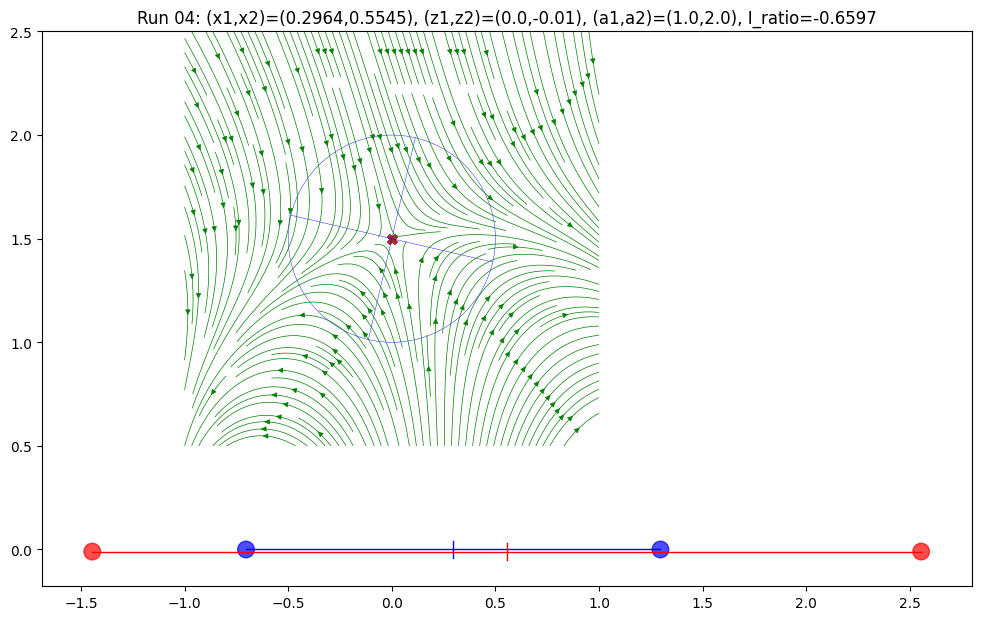

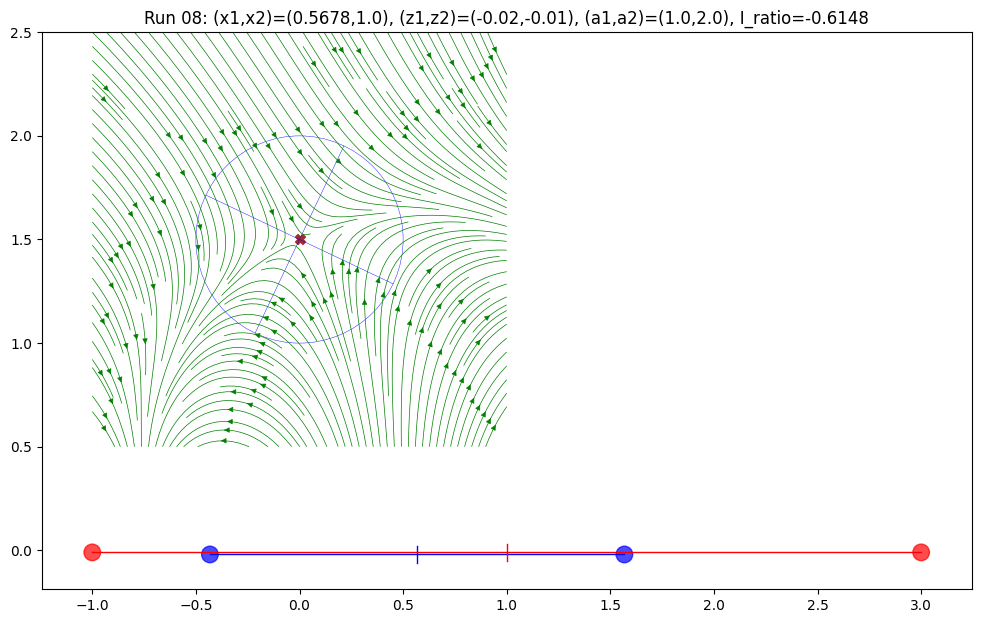

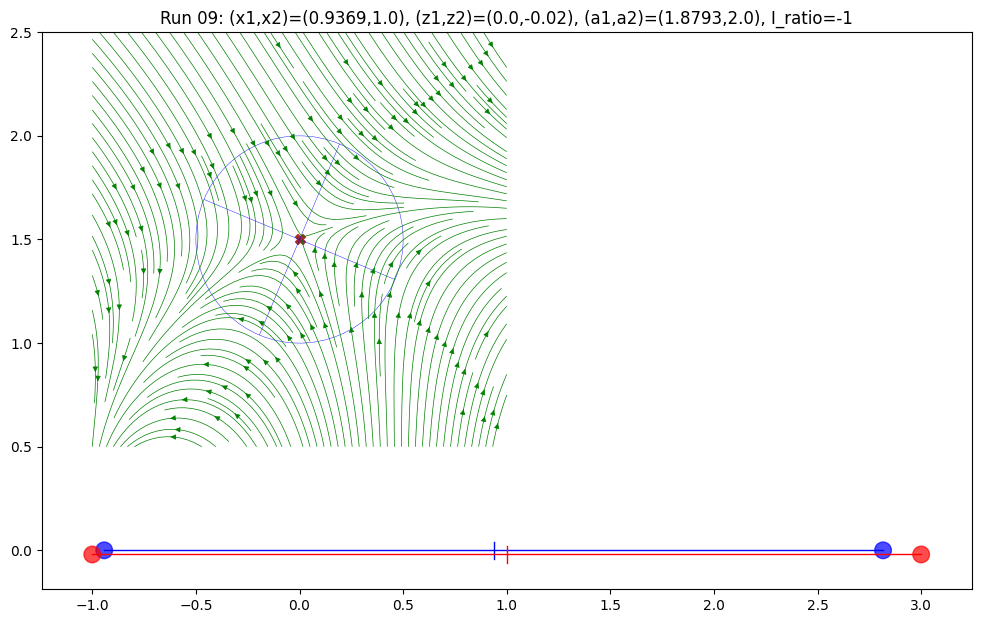

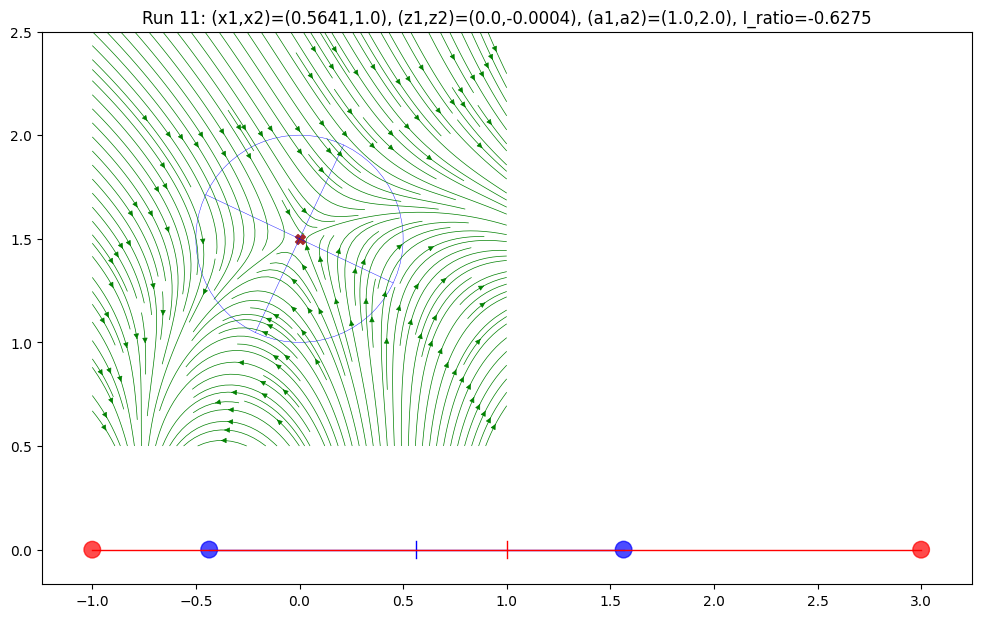

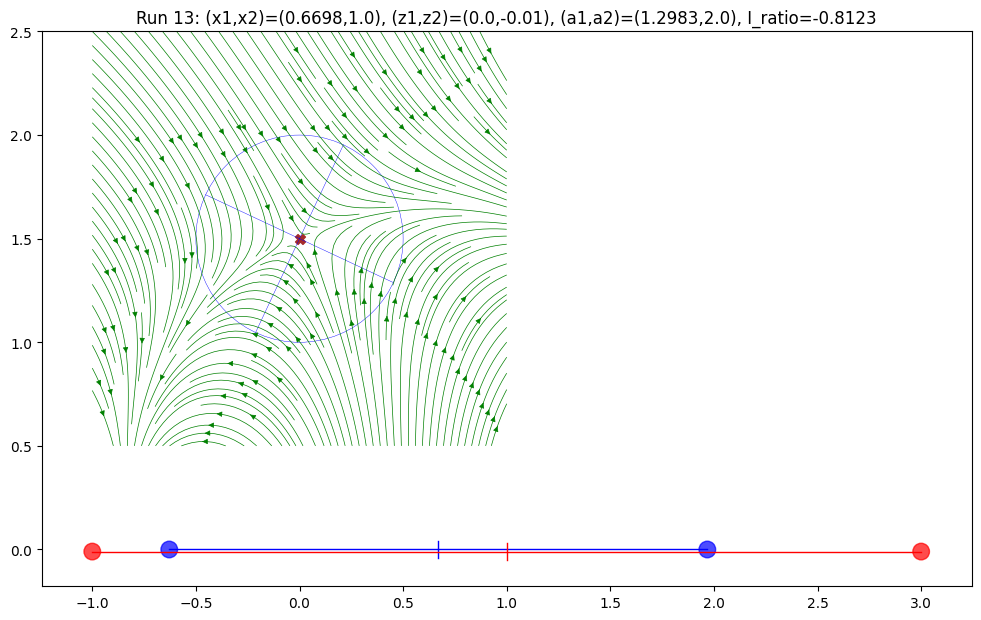

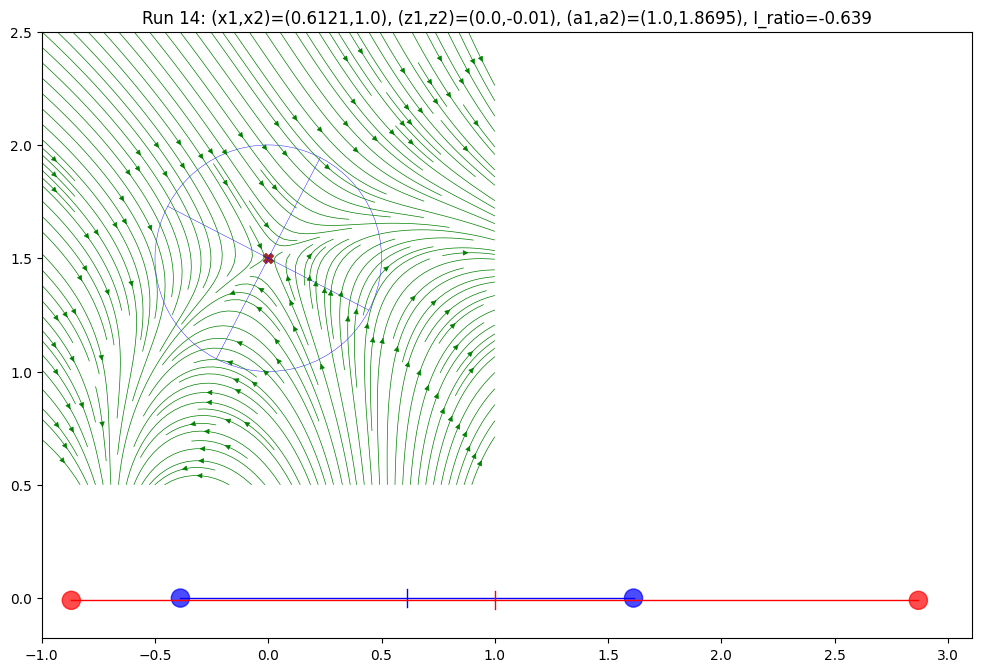

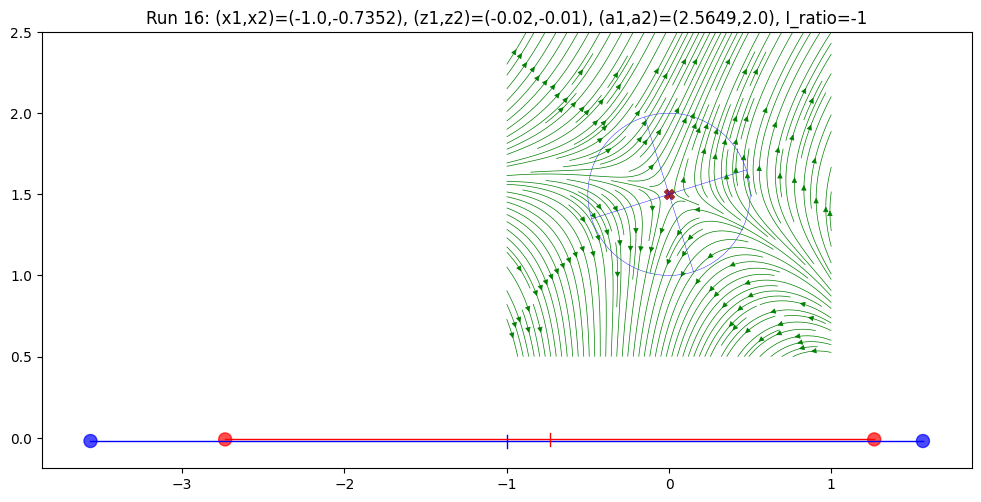

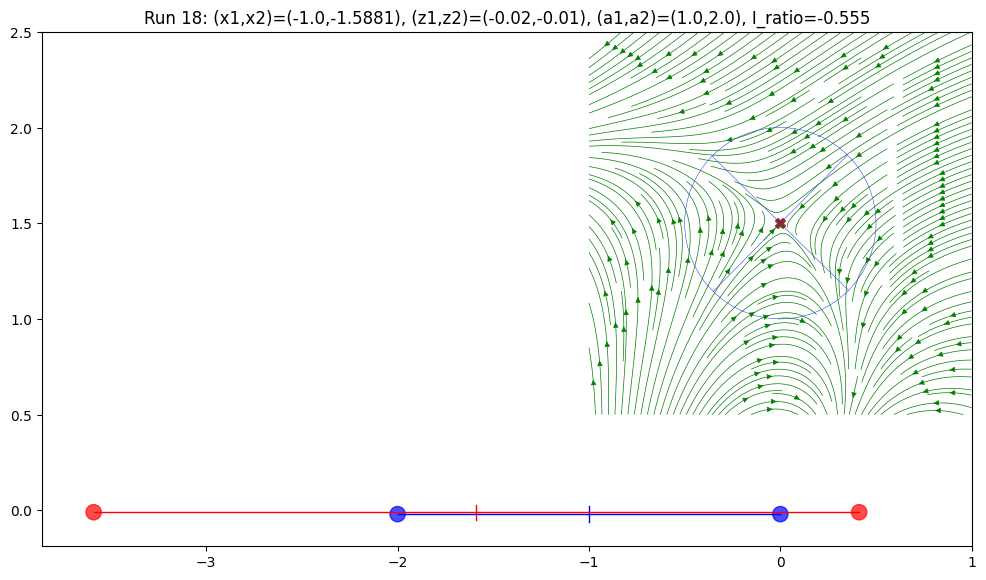

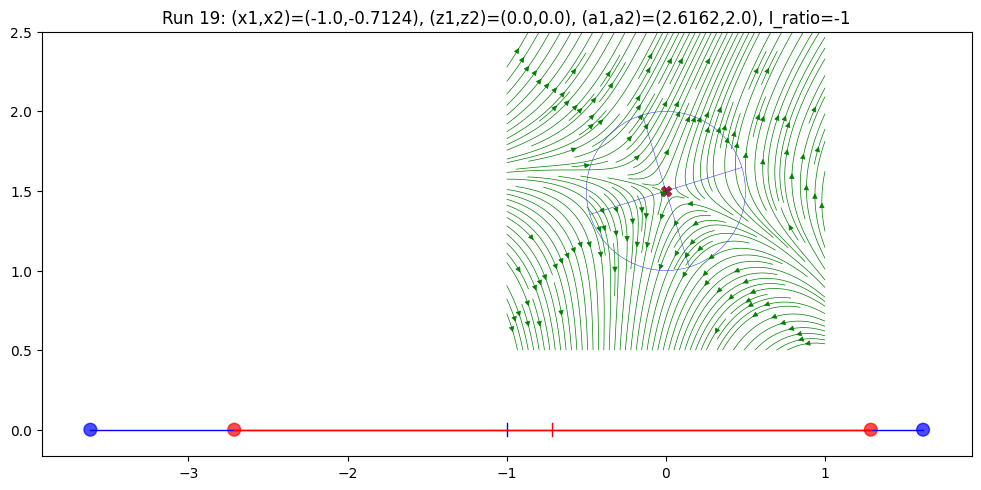

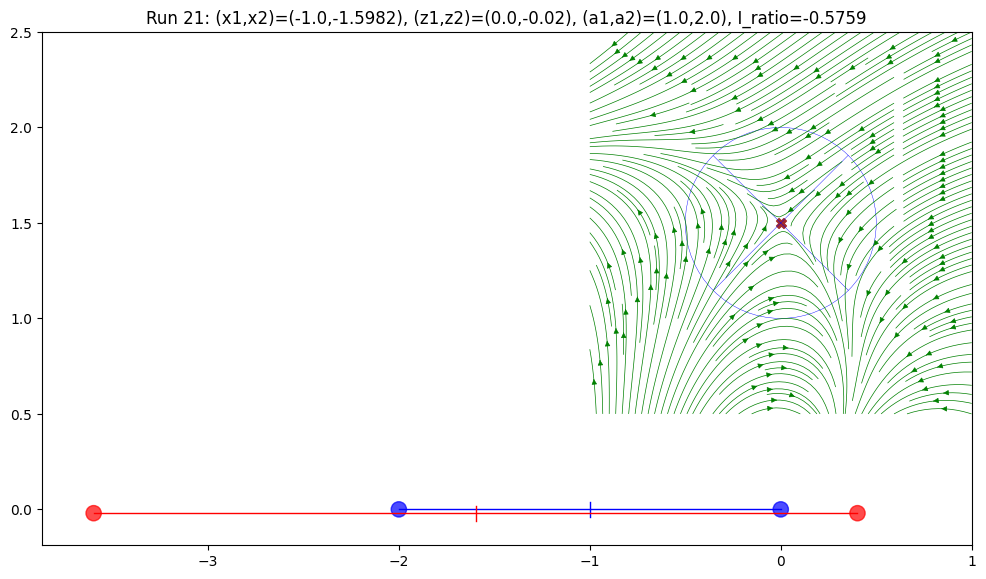

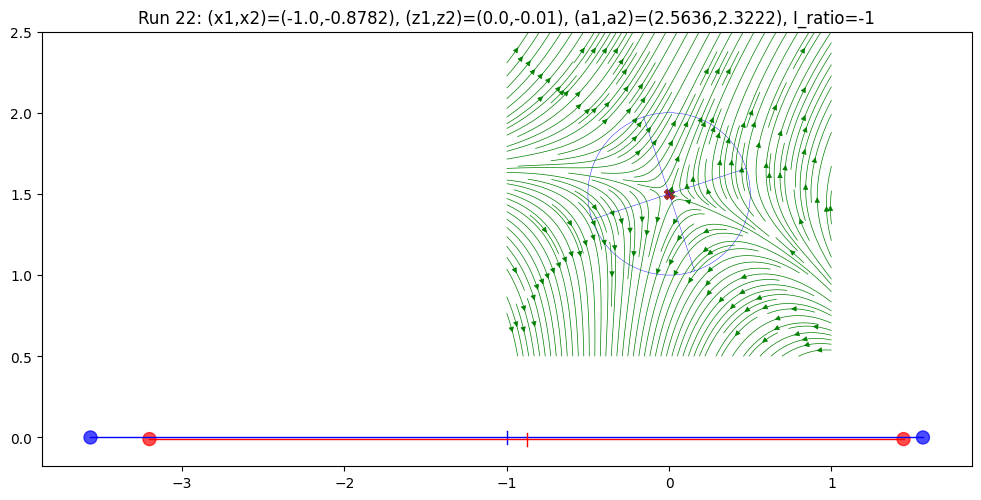

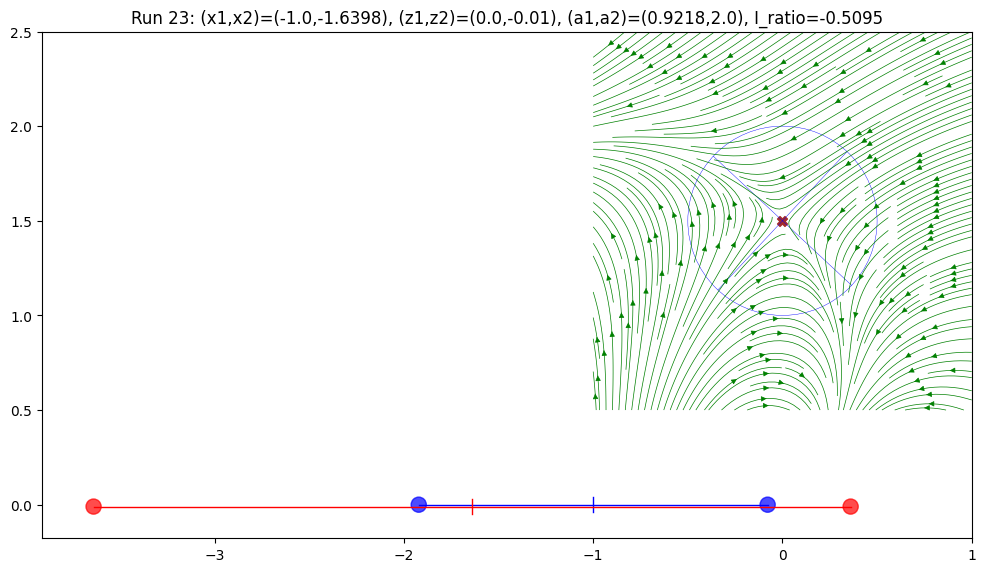

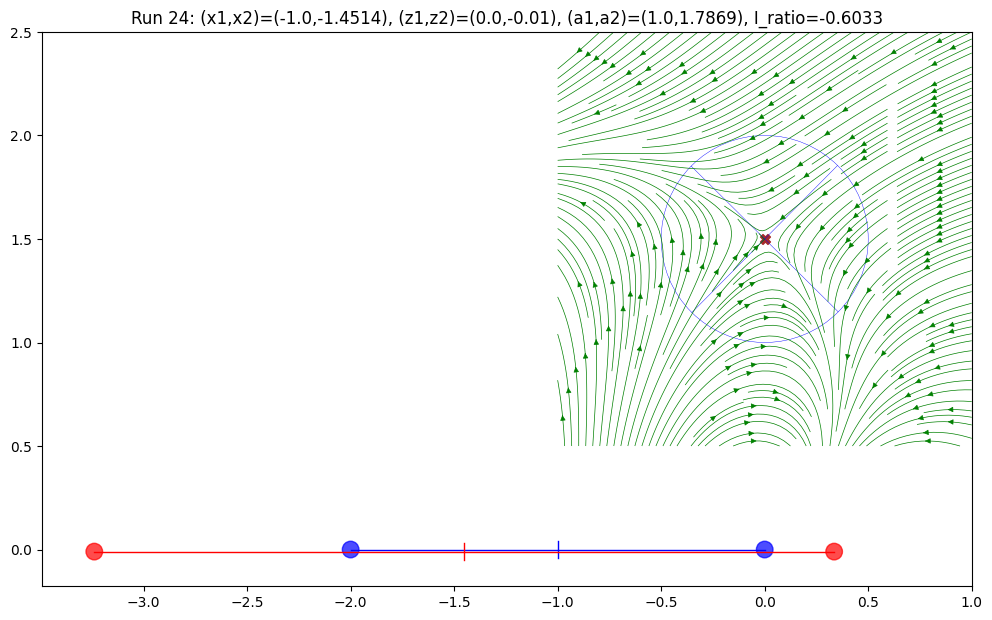

In [48]:
'''
Make plots of magnetic field lines for successful results.
'''
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.lines as lines

def mark_loop(ax, x, z, a, color):
    '''
    Visualize current loop.
    '''
    r = 0.04
    ax.add_patch(Circle((x-a, z), r, color=color, alpha=0.7))
    ax.add_patch(Circle((x+a, z), r, color=color, alpha=0.7))
    ax.add_artist(lines.Line2D([x-a, x+a], [z, z], linewidth=1, color=color))
    ax.add_artist(lines.Line2D([x, x], [z-r, z+r], linewidth=1, color=color))

def mark_x(ax, evec):
    '''
    Mark the field's X-point with a wheel with spokes along the separatrix
    defined by the eigenvectors of the magnitic Jacobian.
    '''
    R = 0.5 # wheel radius
    lw = 0.3
    theta = np.atan2(evec[1], evec[0])
    for i in range(4):
        ax.add_artist(lines.Line2D([null_x, null_x + R*np.cos(theta+i*np.pi/2)],
                                   [null_z, null_z + R*np.sin(theta+i*np.pi/2)],
                                   linewidth=lw, color='blue'))
    ax.add_patch(Circle((null_x, null_z), R, fill=False, color='blue', linewidth=lw))

def plot_field(pp: Params, null_x, null_z, title):
    '''
    Verify visually that the field has a null point at the given (null_x, null_z).
    Also check that the angle of the separatix is correctly computed from the field Jacobian.
    (The latter test so far fails.)
    '''
    focus_on_x = True # draw only in the vicinity of the X-point
    if focus_on_x:
        xmin, xmax = -1, 1
        zmin, zmax =  0.5, 2.5
    else:
        xmin, xmax = -4, 4
        zmin, zmax =  0.1, 3
    xx, zz = np.linspace(xmin, xmax, 150), np.linspace(zmin, zmax, 150)
    xx_grid, zz_grid = np.meshgrid(xx, zz)
    B = total_B(xx_grid, zz_grid, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, 1, pp.I_ratio)
    # print(B)
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    if 1:
        mark_loop(ax, pp.x1, pp.z1, pp.a1, 'blue')
        mark_loop(ax, pp.x2, pp.z2, pp.a2, 'red')
    if 1: # XXX separatrices in mark_x look wrong
        bd = total_B_derivs(null_x, null_z, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, 1, pp.I_ratio)
        evec = compute_jac_eigenvector(bd[0], bd[1], bd[2])
        mark_x(ax, evec)
    ax.scatter(null_x, null_z, s=50, color='brown', marker='X')
    ax.streamplot(xx_grid, zz_grid, B[0], B[1], density=2, color='g',
                    linewidth=0.5, cmap=plt.cm.viridis, arrowsize=0.8)
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.show()

for idx, (vars, result) in enumerate(zip(vars_tuples, results)):
    if result.fun > 1e-6: # normal ~ 1e-11
        continue
    pp = Params()
    for var, value in zip(vars, result.x):
        setattr(pp, var, value) # set pp.<var> = to best values saved in result.x
    if np.abs(pp.x1 - pp.x2) < 0.1 and np.abs(pp.a1 - pp.a2) < 0.1:
        continue # skip loops canceling each other
    title = f'Run {idx:02d}: {pp}'
    plot_field(pp, null_x, null_z, title)